# Notebook 06: Resource Analysis

This notebook is a reader over authoritative reporting artifacts. It now separates:
- **analytic full-pipeline estimates**
- **Qiskit structural subset counts**

The Qiskit structural subset counts **do not validate the full decode-inclusive pipeline**.
They remain useful as implemented-subset structural counts only.
Decode-inclusive analytic estimate and Qiskit structural subset counts are distinct validation scopes.


In [1]:
from pathlib import Path

# cross-model, non-authoritative, not used for claims
# Any such view is diagnostic only and should not replace same-model evidence.

import pandas as pd
import matplotlib.pyplot as plt

try:
    import notebooks._helpers as _nb_helpers
except ModuleNotFoundError:
    import _helpers as _nb_helpers

repo_root = globals().get("repo_root", _nb_helpers.repo_root)
load_metrics_master = globals().get("load_metrics_master", _nb_helpers.load_metrics_master)
load_resources_master = globals().get("load_resources_master", _nb_helpers.load_resources_master)
ensure_run_status_norm = globals().get("ensure_run_status_norm", _nb_helpers.ensure_run_status_norm)
unavailable_panel_table = globals().get("unavailable_panel_table", _nb_helpers.unavailable_panel_table)
placeholder_plot = globals().get("placeholder_plot", _nb_helpers.placeholder_plot)

# ROOT = repo_root()
ROOT = ROOT if "ROOT" in globals() else repo_root()
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.notebook_utils import FilterPipeline
try:
    resources_master = load_resources_master(ROOT / "results", required=False)
except FileNotFoundError:
    resources_master = pd.DataFrame()
resources_master = ensure_run_status_norm(resources_master)
try:
    metrics_master = load_metrics_master(ROOT / "results", required=False)
except FileNotFoundError:
    metrics_master = pd.DataFrame()
metrics_master = ensure_run_status_norm(metrics_master)


In [2]:
PANEL_RESOURCE = "Resource estimation"
PANEL_SAME = "Structure vs decode (same-model authoritative)"
PANEL_CROSS = "Structure vs decode (cross-model diagnostic)"

identity_cols = [
    "slot_id",
    "stage",
    "matrix",
    "instance_id",
    "encoding",
    "decoder",
    "alpha_mode",
    "execution_mode",
]

resource_rows = resources_master.copy() if "resources_master" in globals() else pd.DataFrame()
metric_rows = metrics_master.copy() if "metrics_master" in globals() else pd.DataFrame()
if not resource_rows.empty and "run_status_norm" in resource_rows.columns:
    resource_rows = FilterPipeline(resource_rows, label="resources").filter(
        resource_rows["run_status_norm"] == "completed",
        label="completed_only", reason="run_status_norm == completed"
    ).result()
if not metric_rows.empty and "run_status_norm" in metric_rows.columns:
    metric_rows = FilterPipeline(metric_rows, label="metrics").filter(
        metric_rows["run_status_norm"] == "completed",
        label="completed_only", reason="run_status_norm == completed"
    ).result()

same_model = pd.DataFrame()
cross_model = pd.DataFrame()
same_model_reason = None
cross_model_reason = None

if resource_rows.empty:
    same_model_reason = "resources_master_missing_or_empty"
    cross_model_reason = "resources_master_missing_or_empty"
elif metric_rows.empty:
    same_model_reason = "metrics_master_missing_or_empty"
    cross_model_reason = "metrics_master_missing_or_empty"
else:
    common_identity = [
        c
        for c in identity_cols
        if c in resource_rows.columns and c in metric_rows.columns
    ]
    if not common_identity:
        same_model_reason = "aligned_identity_missing"
        cross_model_reason = "aligned_identity_missing"
    else:
        resource_dupes = resource_rows.duplicated(subset=common_identity, keep=False)
        metric_dupes = metric_rows.duplicated(subset=common_identity, keep=False)
        if resource_dupes.any() or metric_dupes.any():
            same_model_reason = "duplicate_aligned_identity"
            cross_model_reason = "duplicate_aligned_identity"
        else:
            same_model = resource_rows.merge(metric_rows, on=common_identity, how="inner", suffixes=("_resource", "_metric"))
            if same_model.empty:
                same_model_reason = "no_same_model_alignment"
            elif "gain_over_bp1" not in same_model.columns or same_model["gain_over_bp1"].notna().sum() == 0:
                same_model_reason = "same_model_gain_unavailable"
            cross_model = same_model.copy()
            if cross_model.empty or "gain_over_bruteforce" not in cross_model.columns or cross_model["gain_over_bruteforce"].notna().sum() == 0:
                cross_model_reason = "cross_model_gain_unavailable"

if same_model_reason is not None:
    display(
        unavailable_panel_table(
            panel=PANEL_SAME,
            reason=same_model_reason,
            details="Same-model authoritative structure/decode alignment is unavailable for this slice.",
        )
    )
else:
    print(f"{PANEL_SAME}: {len(same_model)} row(s) aligned on same-model identity.")
    if "gain_over_bp1" in same_model.columns:
        gain_rows = same_model["gain_over_bp1"].notna().sum()
        print(f"Rows with same-model same-family evidence: {int(gain_rows)} / {len(same_model)}")

if cross_model_reason is not None:
    display(
        unavailable_panel_table(
            panel=PANEL_CROSS,
            reason=cross_model_reason,
            details="Cross-model comparisons remain diagnostic only and are not merged with full-scope parity evidence.",
        )
    )
else:
    print(
        "Cross-model diagnostic data exists but is intentionally kept separate from full Pipeline and structural-subset scopes."
    )



Structure vs decode (same-model authoritative): 140 row(s) aligned on same-model identity.
Rows with same-model same-family evidence: 79 / 140
Cross-model diagnostic data exists but is intentionally kept separate from full Pipeline and structural-subset scopes.


## Scope Split Summary

Decode-inclusive analytic estimate and Qiskit structural subset counts are distinct validation scopes.
This compact table keeps the scopes side by side so the notebook does not imply that Qiskit counts validate the decode-inclusive pipeline.


In [3]:
scope_contract = {
    "analytic_scope": "full_pipeline_estimate",
    "qiskit_scope": "structural_subset_only",
    "note": (
        "Decode-inclusive analytic estimate and Qiskit structural subset counts are distinct validation scopes."
    ),
}
summary_cols = [
    "artifact / instance",
    "analytic_scope",
    "qiskit_scope",
    "decode_included?",
    "comparable?",
    "analytic_gate_est_with_decode",
    "analytic_depth_est_with_decode",
    "analytic_qubits_with_decode",
    "qiskit_structural_count_note",
]

if resources_master.empty:
    display(
        unavailable_panel_table(
            panel="Resource scope summary",
            reason="resources_master is missing or empty.",
        )
    )
    scope_summary_df = pd.DataFrame()
else:
    scope_summary_df = resources_master.copy()
    if "run_status_norm" in scope_summary_df.columns:
        scope_summary_df = scope_summary_df[scope_summary_df["run_status_norm"] == "completed"].copy()
    scope_summary_df = scope_summary_df.assign(
        analytic_scope=scope_contract["analytic_scope"],
        qiskit_scope=scope_contract["qiskit_scope"],
        **{
            "artifact / instance": scope_summary_df.get("instance_id", pd.Series(dtype=object)),
            "decode_included?": "analytic: yes; qiskit: no",
            "comparable?": "no",
            "analytic_gate_est_with_decode": scope_summary_df.get(
                "resource_total_gate_est_with_decode", pd.Series(dtype=float)
            ),
            "analytic_depth_est_with_decode": scope_summary_df.get(
                "resource_total_depth_est_with_decode", pd.Series(dtype=float)
            ),
            "analytic_qubits_with_decode": scope_summary_df.get(
                "resource_total_qubits_est_with_decode", pd.Series(dtype=float)
            ),
            "qiskit_structural_count_note": (
                "Qiskit values are structural-subset-only and remain separate from full decode-inclusive evidence. "
                "Availability is row-level and may be absent when upstream nested payload is not present."
            ),
        },
    )
    display(scope_summary_df[[c for c in summary_cols if c in scope_summary_df.columns]].head(20))

display(pd.DataFrame([scope_contract]))



,artifact / instance,analytic_scope,qiskit_scope,decode_included?,comparable?,analytic_gate_est_with_decode,analytic_depth_est_with_decode,analytic_qubits_with_decode,qiskit_structural_count_note
39,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,396.0,182.0,19.0,Qiskit values are structural-subset-only and r...
40,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,5136.0,615.0,21.0,Qiskit values are structural-subset-only and r...
41,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,396.0,182.0,19.0,Qiskit values are structural-subset-only and r...
42,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,5136.0,615.0,21.0,Qiskit values are structural-subset-only and r...
43,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,396.0,182.0,19.0,Qiskit values are structural-subset-only and r...
44,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,5136.0,615.0,21.0,Qiskit values are structural-subset-only and r...
45,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,396.0,182.0,19.0,Qiskit values are structural-subset-only and r...
46,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,5136.0,615.0,21.0,Qiskit values are structural-subset-only and r...
47,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,396.0,182.0,19.0,Qiskit values are structural-subset-only and r...
48,C1,full_pipeline_estimate,structural_subset_only,analytic: yes; qiskit: no,no,5136.0,615.0,21.0,Qiskit values are structural-subset-only and r...


,analytic_scope,qiskit_scope,note
0,full_pipeline_estimate,structural_subset_only,Decode-inclusive analytic estimate and Qiskit ...


## Analytic Full-Pipeline Estimates (primary reviewer-facing scope)

This section reads decode-inclusive analytic estimates from the reporting layer and is the primary resource result for this notebook.
These rows are the reviewer-facing evidence for full-pipeline cost estimates.


,instance_id,matrix,encoding,decoder,alpha_mode,execution_mode,resource_total_gate_est_with_decode,resource_total_depth_est_with_decode,resource_total_qubits_est_with_decode,problem_size
39,C1,matrix_b,wht_exact,oracle,uniform,mixture,396.0,182.0,19.0,0.0
40,C1,matrix_b,wht_exact,bp1,uniform,mixture,5136.0,615.0,21.0,1.0
41,C1,matrix_b,wht_exact,oracle,uniform,coherent,396.0,182.0,19.0,2.0
42,C1,matrix_b,wht_exact,bp1,uniform,coherent,5136.0,615.0,21.0,3.0
43,C1,matrix_b,wht_exact,oracle,paper,mixture,396.0,182.0,19.0,4.0
44,C1,matrix_b,wht_exact,bp1,paper,mixture,5136.0,615.0,21.0,5.0
45,C1,matrix_b,wht_exact,oracle,paper,coherent,396.0,182.0,19.0,6.0
46,C1,matrix_b,wht_exact,bp1,paper,coherent,5136.0,615.0,21.0,7.0
47,C1,matrix_b,wht_exact,oracle,heuristic,mixture,396.0,182.0,19.0,8.0
48,C1,matrix_b,wht_exact,bp1,heuristic,mixture,5136.0,615.0,21.0,9.0


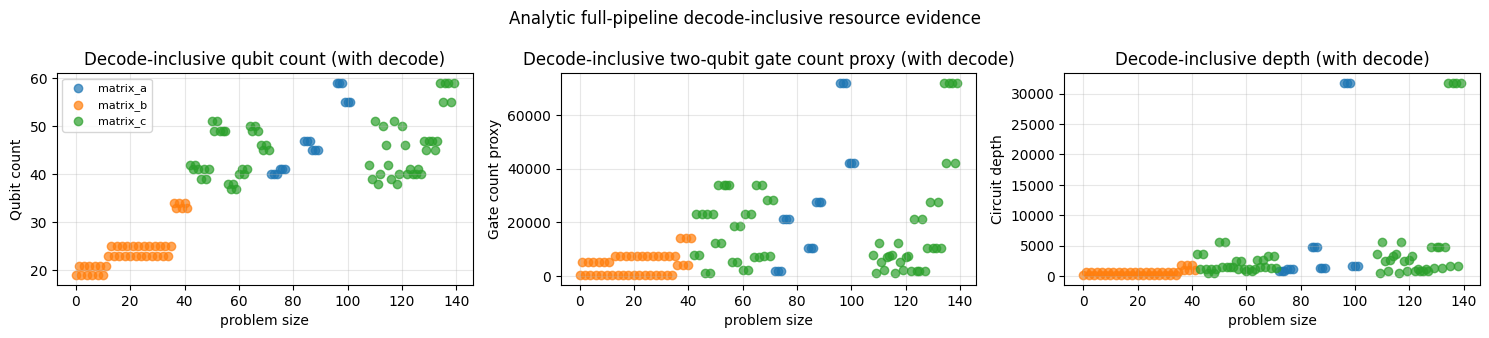

In [4]:
from _helpers import unavailable_or_numeric


def _extract_problem_size(rows: pd.DataFrame) -> pd.Series:
    if "instance_id" in rows.columns:
        problem_size = pd.to_numeric(
            rows["instance_id"].astype(str).str.extract(r"(\\d+)$")[0],
            errors="coerce",
        )
    else:
        problem_size = pd.Series([float("nan")] * len(rows), index=rows.index)

    if problem_size.isna().all() and "m_error_qubits" in rows.columns:
        problem_size = pd.to_numeric(rows["m_error_qubits"], errors="coerce")

    if problem_size.isna().all():
        problem_size = pd.Series(range(len(rows)), index=rows.index, dtype=float)

    return problem_size


analytic_cols = [
    "instance_id",
    "matrix",
    "encoding",
    "decoder",
    "alpha_mode",
    "execution_mode",
    "resource_total_gate_est_with_decode",
    "resource_total_depth_est_with_decode",
    "resource_total_qubits_est_with_decode",
    "resource_validation_scope",
]

if resources_master.empty:
    display(
        unavailable_panel_table(
            panel="Analytic full-pipeline estimates",
            reason="resources_master is missing or empty.",
        )
    )
    analytic_df = pd.DataFrame()
else:
    analytic_df = resources_master.copy()
    if "run_status_norm" in analytic_df.columns:
        analytic_df = analytic_df[analytic_df["run_status_norm"] == "completed"].copy()

    for metric in [
        "resource_total_gate_est_with_decode",
        "resource_total_depth_est_with_decode",
        "resource_total_qubits_est_with_decode",
    ]:
        if metric in analytic_df.columns:
            analytic_df = unavailable_or_numeric(analytic_df, metric)
            mask = analytic_df[f"{metric}_status"] == "unavailable"
            analytic_df[metric] = analytic_df[metric].astype(object)
            analytic_df.loc[mask, metric] = "absent from payload"

    analytic_df = analytic_df[[c for c in analytic_cols if c in analytic_df.columns]].copy()
    analytic_df["problem_size"] = _extract_problem_size(analytic_df)

    display(analytic_df.head(20))

    if not analytic_df.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
        metrics = [
            (
                "resource_total_qubits_est_with_decode",
                "Decode-inclusive qubit count (with decode)",
                "Qubit count",
            ),
            (
                "resource_total_gate_est_with_decode",
                "Decode-inclusive two-qubit gate count proxy (with decode)",
                "Gate count proxy",
            ),
            (
                "resource_total_depth_est_with_decode",
                "Decode-inclusive depth (with decode)",
                "Circuit depth",
            ),
        ]

        for ax, metric_spec in zip(axes, metrics):
            metric_name, title, ylabel = metric_spec
            numeric_metric = pd.to_numeric(analytic_df.get(metric_name), errors="coerce")
            metric_df = analytic_df.copy()
            metric_df["metric_value"] = numeric_metric
            if "problem_size" in metric_df.columns:
                metric_df = metric_df.dropna(subset=["problem_size", "metric_value"]).copy()

            if metric_df.empty:
                ax.axis("off")
                ax.text(
                    0.04,
                    0.56,
                    "No numeric rows available for this panel.\nThis is expected when data is intentionally absent in the current slice.",
                    transform=ax.transAxes,
                )
                ax.set_title(title)
                continue

            groups = metric_df.groupby("matrix") if "matrix" in metric_df.columns else [("all", metric_df)]
            for group_name, group_df in groups:
                ax.scatter(
                    group_df["problem_size"],
                    group_df["metric_value"],
                    alpha=0.7,
                    label=str(group_name),
                )

            ax.set_title(title)
            ax.set_xlabel("problem size")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.3)

        if "matrix" in analytic_df.columns:
            axes[0].legend(fontsize=8)

        fig.suptitle("Analytic full-pipeline decode-inclusive resource evidence")
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    else:
        display(
            unavailable_panel_table(
                panel="Analytic full-pipeline resource plots",
                reason="no_analytic_rows",
                details="No completed rows available for analytic plotting in this slice.",
            )
        )



## Qiskit Structural-Subset Evidence (supplementary)

Qiskit structural-subset data is a supplementary validation layer only.
It covers implemented structural-subset transpilation artifacts and does not validate the full decode-inclusive pipeline.
When subset payloads are absent or too sparse in the current canonical payload, this section falls back to a compact availability audit.


Qiskit structural-subset payload availability for completed rows: 122 / 140 (87.1%).
Rows marked absent from payload are row-level and should be read as subset artifact unavailable for current row, not a pipeline failure.


,qiskit_payload_status,rows,row_level_note
0,available,122,subset artifact available for current row
1,partial,0,subset artifact partially available; at least ...
2,absent from payload,18,subset artifact unavailable for current row


,instance_id,qiskit_scope,decode_included,comparable,qiskit_transpiled_depth,qiskit_cx_count,qiskit_qubit_count,qiskit_payload_status
39,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
40,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
41,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
42,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
43,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
44,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
45,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
46,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
47,C1,structural_subset_only,False,False,9.0,4.0,8.0,available
48,C1,structural_subset_only,False,False,9.0,4.0,8.0,available


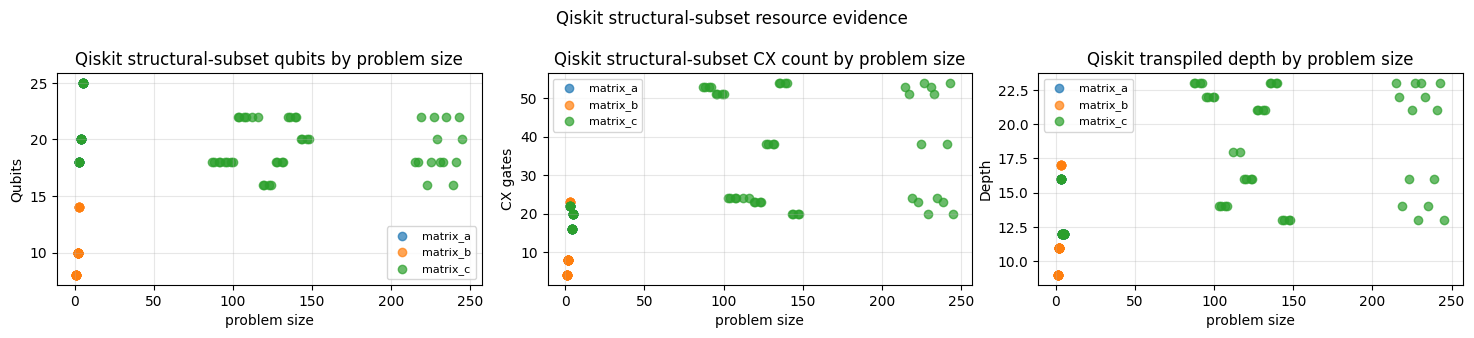

In [5]:
import json
from pathlib import Path
from typing import Any


qiskit_cols = [
    "instance_id",
    "qiskit_scope",
    "decode_included",
    "comparable",
    "qiskit_transpiled_depth",
    "qiskit_cx_count",
    "qiskit_qubit_count",
    "qiskit_payload_status",
]

# Flattened convenience fields produced by upstream propagation (Stage 1 fix)
QISKIT_FLAT_COLUMNS = {
    "qiskit_transpiled_depth": ["qiskit_subset_transpiled_depth"],
    "qiskit_cx_count": ["qiskit_subset_cx_count"],
    "qiskit_qubit_count": ["qiskit_subset_qubit_count"],
}

QISKIT_SOURCE_COLUMNS = [
    "qiskit_subset_resource_report",
    "qiskit_transpiled_structural_count",
    "implemented_resources",
    "analytic_estimates",
    "total_estimated_resources",
    "resources",
]

QISKIT_PATH_COLUMNS = ["observed_report_path", "observed_resources_path"]

QISKIT_PRIMARY_FIELDS = {
    "qiskit_transpiled_depth": ["transpiled_depth"],
    "qiskit_cx_count": ["cx_count"],
    "qiskit_qubit_count": ["qubit_count"],
}

QISKIT_FALLBACK_FIELDS = {
    "qiskit_transpiled_depth": ["depth"],
    "qiskit_cx_count": ["two_qubit_gates", "cx", "cx_count_by_scope"],
    "qiskit_qubit_count": ["n_qubits", "qubits", "num_qubits"],
}


def _parse_payload_value(value: Any):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return None
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return None
        try:
            payload = json.loads(s)
        except json.JSONDecodeError:
            return None
        return payload if isinstance(payload, dict) else None
    return None


def _extract_qiskit_metrics(payload: dict[str, Any], status_parts: list[str]) -> dict[str, Any]:
    row_data: dict[str, Any] = {}
    for metric, primary in QISKIT_PRIMARY_FIELDS.items():
        value = None
        for key in primary + QISKIT_FALLBACK_FIELDS[metric]:
            candidate = payload.get(key)
            if candidate is None or pd.isna(candidate):
                continue
            value = candidate
            break
        if value is None and metric == "qiskit_cx_count":
            gate_counts = payload.get("gate_counts")
            if isinstance(gate_counts, dict):
                for gate_key in ("cx", "two_qubit_gates"):
                    gate_value = gate_counts.get(gate_key)
                    if gate_value is not None and not pd.isna(gate_value):
                        value = gate_value
                        break

        if value is None or pd.isna(value):
            row_data[metric] = "absent from payload"
            status_parts.append(f"{metric}:absent")
        else:
            row_data[metric] = value
            status_parts.append(f"{metric}:present")
    return row_data


def _unpack_payload(payload: Any) -> tuple[dict[str, Any] | None, str | None]:
    if not isinstance(payload, dict):
        return None, None

    for key in ["qiskit_subset_resource_report", "qiskit_transpiled_structural_count"]:
        nested = payload.get(key)
        if isinstance(nested, dict):
            return nested, key

    for key in ["implemented_resources", "analytic_estimates", "total_estimated_resources", "resources"]:
        nested = payload.get(key)
        if isinstance(nested, dict):
            nested_payload, nested_source = _unpack_payload(nested)
            if nested_payload is not None:
                return nested_payload, f"{key}.{nested_source}" if nested_source else key

    metric_keys = {
        *QISKIT_PRIMARY_FIELDS["qiskit_transpiled_depth"],
        *QISKIT_PRIMARY_FIELDS["qiskit_cx_count"],
        *QISKIT_PRIMARY_FIELDS["qiskit_qubit_count"],
        *QISKIT_FALLBACK_FIELDS["qiskit_transpiled_depth"],
        *QISKIT_FALLBACK_FIELDS["qiskit_cx_count"],
        *QISKIT_FALLBACK_FIELDS["qiskit_qubit_count"],
    }
    if any(key in payload for key in metric_keys):
        return payload, "inline"
    return None, None


def _row_matches_candidate(row: pd.Series, candidate: dict[str, Any]) -> bool:
    if not isinstance(candidate, dict):
        return False
    for key in [
        "run_id",
        "slot_id",
        "matrix",
        "instance_id",
        "encoding",
        "decoder",
        "alpha_mode",
        "execution_mode",
    ]:
        if key not in candidate or key not in row:
            continue
        row_value = row.get(key)
        candidate_value = candidate.get(key)
        if pd.isna(row_value) and pd.isna(candidate_value):
            continue
        if str(row_value) != str(candidate_value):
            return False
    return True


def _extract_from_path(path_str: Any, row: pd.Series) -> tuple[dict[str, Any] | None, str | None]:
    if pd.isna(path_str):
        return None, None

    p = Path(str(path_str))
    if not p.exists() or p.suffix.lower() not in {".json"}:
        return None, None

    with open(p, "r") as f:
        payload = json.load(f)

    candidate_records: list[Any]
    if isinstance(payload, dict):
        candidates = payload.get("records")
        if isinstance(candidates, list):
            candidate_records = candidates
        else:
            candidate_records = [payload]
    elif isinstance(payload, list):
        candidate_records = payload
    else:
        return None, None

    for candidate in candidate_records:
        if not isinstance(candidate, dict):
            continue
        if not _row_matches_candidate(row, candidate):
            continue
        nested, nested_source = _unpack_payload(candidate)
        if nested is not None:
            return nested, nested_source

        # Some paths may point directly at a qiskit subset payload
        if any(
            key in candidate
            for key in [
                "qiskit_subset_resource_report",
                "qiskit_transpiled_structural_count",
            ]
        ):
            nested, nested_source = _unpack_payload(candidate)
            if nested is not None:
                return nested, nested_source

    return None, None


def _extract_from_flat_columns(row: pd.Series) -> dict[str, Any] | None:
    """Check flattened convenience columns produced by upstream propagation."""
    result: dict[str, Any] = {}
    found_any = False
    
    for metric, flat_cols in QISKIT_FLAT_COLUMNS.items():
        value = None
        for col in flat_cols:
            candidate = row.get(col)
            if candidate is not None and not pd.isna(candidate):
                value = candidate
                found_any = True
                break
        result[metric] = value
    
    # Also check qiskit_subset_status for availability signal
    status = row.get("qiskit_subset_status")
    if status == "ok":
        found_any = True
    
    return result if found_any else None


def extract_qiskit_subset(row: pd.Series) -> pd.Series:
    # First: check flattened convenience columns from upstream propagation
    flat_data = _extract_from_flat_columns(row)
    if flat_data is not None:
        status_parts: list[str] = []
        for metric in ["qiskit_transpiled_depth", "qiskit_cx_count", "qiskit_qubit_count"]:
            val = flat_data.get(metric)
            if val is not None and not pd.isna(val):
                status_parts.append(f"{metric}:present")
            else:
                flat_data[metric] = "absent from payload"
                status_parts.append(f"{metric}:absent")
        
        present_count = sum(part.endswith(":present") for part in status_parts)
        return pd.Series(
            {
                "qiskit_transpiled_depth": flat_data["qiskit_transpiled_depth"],
                "qiskit_cx_count": flat_data["qiskit_cx_count"],
                "qiskit_qubit_count": flat_data["qiskit_qubit_count"],
                "qiskit_payload_status": "available" if present_count == 3 else (
                    "partial" if present_count > 0 else "absent from payload"
                ),
            }
        )
    
    # Second: check nested payload columns
    payload = None
    payload_source: str | None = None

    for col in QISKIT_SOURCE_COLUMNS:
        parsed = _parse_payload_value(row.get(col))
        if parsed is None:
            continue
        candidate, candidate_source = _unpack_payload(parsed)
        if candidate is not None:
            payload = candidate
            payload_source = f"{col}:{candidate_source}"
            break

    if payload is None:
        for path_col in QISKIT_PATH_COLUMNS:
            path_payload, path_source = _extract_from_path(row.get(path_col), row)
            if path_payload is not None:
                payload = path_payload
                payload_source = f"{path_col}:{path_source}"
                break

    if payload is None:
        return pd.Series(
            {
                "qiskit_transpiled_depth": "absent from payload",
                "qiskit_cx_count": "absent from payload",
                "qiskit_qubit_count": "absent from payload",
                "qiskit_payload_status": "absent from payload",
            }
        )

    status_parts: list[str] = []
    extracted = _extract_qiskit_metrics(payload, status_parts)
    present_count = sum(part.endswith(":present") for part in status_parts)

    return pd.Series(
        {
            "qiskit_transpiled_depth": extracted["qiskit_transpiled_depth"],
            "qiskit_cx_count": extracted["qiskit_cx_count"],
            "qiskit_qubit_count": extracted["qiskit_qubit_count"],
            "qiskit_payload_status": "available" if present_count == 3 else (
                "partial" if present_count > 0 else "absent from payload"
            ),
        }
    )


def _problem_size(rows: pd.DataFrame) -> pd.Series:
    if "instance_id" not in rows.columns:
        return pd.Series(range(len(rows)), index=rows.index, dtype=float)
    parsed_size = pd.to_numeric(rows["instance_id"].astype(str).str.extract(r"(\d+)$")[0], errors="coerce")
    fallback_size = pd.Series(rows.index, index=rows.index, dtype=float)
    return parsed_size.fillna(pd.to_numeric(fallback_size, errors="coerce")).astype(float)


qiskit_df = resources_master.copy()
if "run_status_norm" in qiskit_df.columns:
    qiskit_df = qiskit_df[qiskit_df["run_status_norm"] == "completed"].copy()

if qiskit_df.empty:
    display(
        unavailable_panel_table(
            panel="Qiskit structural subset counts",
            reason="resources_master is missing or empty.",
        )
    )
else:
    scope_contract = {
        "analytic_scope": "full_pipeline_estimate",
        "qiskit_scope": "structural_subset_only",
        "note": (
            "Decode-inclusive analytic estimate and Qiskit structural subset counts are distinct validation scopes."
        ),
    }

    extracted = qiskit_df.apply(extract_qiskit_subset, axis=1)
    qiskit_df = pd.concat([qiskit_df, extracted], axis=1)
    qiskit_df = qiskit_df.assign(
        qiskit_scope=scope_contract["qiskit_scope"],
        decode_included=False,
        comparable=False,
        problem_size=_problem_size(qiskit_df),
    )

    sort_cols = [c for c in ["instance_id", "problem_size"] if c in qiskit_df.columns]
    if sort_cols:
        qiskit_df = qiskit_df.sort_values(sort_cols, na_position="first", kind="mergesort")

    status_labels = {
        "available": "subset artifact available for current row",
        "partial": "subset artifact partially available; at least one metric missing for current row",
        "absent from payload": "subset artifact unavailable for current row",
    }
    status_index = ["available", "partial", "absent from payload"]
    status_counts = (
        qiskit_df["qiskit_payload_status"].value_counts(dropna=False)
        .reindex(status_index, fill_value=0)
    )
    qiskit_payload_audit = pd.DataFrame(
        {
            "qiskit_payload_status": status_counts.index,
            "rows": status_counts.astype(int).values,
        }
    )
    qiskit_payload_audit = qiskit_payload_audit.assign(
        row_level_note=qiskit_payload_audit["qiskit_payload_status"].map(status_labels),
    )

    total_rows = int(len(qiskit_df))
    available_rows = int(status_counts.get("available", 0))
    availability_fraction = (available_rows / total_rows) if total_rows else 0.0
    availability_percent = availability_fraction * 100

    render_threshold_rows = 8
    render_threshold_fraction = 0.25
    render_qiskit_panel = (available_rows >= render_threshold_rows) and (
        availability_fraction >= render_threshold_fraction
    )

    print(
        f"Qiskit structural-subset payload availability for completed rows: {available_rows} / {total_rows} ({availability_percent:.1f}%)."
    )
    print(
        "Rows marked absent from payload are row-level and should be read as subset artifact unavailable for current row, not a pipeline failure."
    )
    display(qiskit_payload_audit)

    if render_qiskit_panel:
        qiskit_table = qiskit_df[[c for c in qiskit_cols if c in qiskit_df.columns]].copy()
        display(qiskit_table.head(20))

        fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
        metric_specs = [
            ("qiskit_qubit_count", "Qiskit structural-subset qubits by problem size", "Qubits"),
            ("qiskit_cx_count", "Qiskit structural-subset CX count by problem size", "CX gates"),
            ("qiskit_transpiled_depth", "Qiskit transpiled depth by problem size", "Depth"),
        ]

        for ax, metric_spec in zip(axes, metric_specs):
            metric_name, title, ylabel = metric_spec
            metric_values = pd.to_numeric(qiskit_df.get(metric_name), errors="coerce")
            metric_plot_df = qiskit_df.copy()
            metric_plot_df["metric_value"] = metric_values
            metric_plot_df = metric_plot_df.dropna(subset=["metric_value", "problem_size"])

            if metric_plot_df.empty:
                ax.axis("off")
                ax.text(
                    0.04,
                    0.56,
                    "No extracted numeric rows for this panel." + chr(10) +
                    "No numeric data for review at this threshold.",
                    transform=ax.transAxes,
                )
                ax.set_title(title)
                continue

            if "matrix" in metric_plot_df.columns:
                for matrix_name, matrix_rows in metric_plot_df.groupby("matrix"):
                    ax.scatter(
                        matrix_rows["problem_size"],
                        matrix_rows["metric_value"],
                        alpha=0.7,
                        label=str(matrix_name),
                    )
                ax.legend(fontsize=8)
            else:
                ax.scatter(metric_plot_df["problem_size"], metric_plot_df["metric_value"], alpha=0.7)

            ax.set_title(title)
            ax.set_xlabel("problem size")
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.3)

        fig.suptitle("Qiskit structural-subset resource evidence")
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    else:
        if available_rows == 0:
            print("Qiskit structural-subset artifacts are absent from payload for all completed rows in this canonical slice.")
            print("This is a payload-availability condition and does not undermine full-pipeline analytic evidence.")
        else:
            print(
                "Subset artifacts are available for only a sparse subset of rows; too sparse for reviewer-facing structural-subset plot."
            )
            print("This section is therefore a compact supplementary audit only.")

        compact_rows = qiskit_df[qiskit_df["qiskit_payload_status"] == "available"][
            [c for c in qiskit_cols if c in qiskit_df.columns]
        ].head(10)
        if not compact_rows.empty:
            print("Compact sample of rows with usable subset artifacts:")
            display(compact_rows)
        else:
            print("No usable subset-artifact rows are available to display.")
